# Llm deliberation acceptance boundary

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 07
## LLM-Deliberation controlled acceptance boundary

This notebook returns to the frozen negotiation environment with the measurement repairs validated in the previous experiment.

The primary scientific object is now a **state-level revealed acceptance boundary**, not a proposed-deal score and not the immediate action token itself.

For each of the 30 already-frozen parent states:

1. verify the immutable parent snapshot and private score table;
2. capture an all-layer parent-state activation **before any candidate deal is revealed**;
3. deterministically construct a candidate-deal score grid from the saved legal utility table;
4. replay independent candidate deals from the same parent state;
5. make ACCEPT / REJECT a one-token consequential choice;
6. estimate a score boundary from the resulting behavioral choices;
7. compare the state-level boundary against a parent-state activation reader and strong non-activation baselines.

The candidate action branches are measurement forks only. They never modify or continue the saved source trajectory.

Primary target:

`rho_norm = (revealed boundary score - legal minimum score) / legal score span`

Primary uncertainty clusters by the **five source trajectories**.

All artifacts are isolated under:

`/workspace/latent-reservations/notebook_outputs/07_llm_deliberation_acceptance_boundary/<RUN_ID>/`


In [1]:
NOTEBOOK_BUILD = "latent-reservations-notebook07-llm-deliberation-acceptance-boundary-v1"
print("=" * 86)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("LLM-Deliberation controlled acceptance-boundary experiment")
print("=" * 86)


NOTEBOOK BUILD: latent-reservations-notebook07-llm-deliberation-acceptance-boundary-v1
LLM-Deliberation controlled acceptance-boundary experiment


## 1. Dependencies


In [2]:
import importlib.util
import subprocess
import sys

packages = [
    "transformers>=4.45,<5",
    "accelerate>=0.30,<2",
    "safetensors>=0.4",
    "numpy<2",
    "pandas>=2,<3",
    "scipy>=1.12,<2",
    "scikit-learn>=1.4,<2",
    "matplotlib>=3.8,<4",
    "tqdm>=4.66",
]
subprocess.run([sys.executable, "-m", "pip", "install", *packages], check=True)

if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required in the active environment.")

print("Notebook 07 dependencies ready.")


Notebook 07 dependencies ready.


## 2. Paths and isolated run directory


In [3]:
from __future__ import annotations

import hashlib
import itertools
import json
import os
import random
import re
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path(
    os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")
).expanduser().resolve()

NOTEBOOK_SLUG = "07_llm_deliberation_acceptance_boundary"
RUN_ID = os.environ.get(
    "LR_RUN_ID",
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"),
)

NOTEBOOK_OUTPUT_BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_OUTPUT_DIR = NOTEBOOK_OUTPUT_BASE / RUN_ID

MANIFEST_DIR = RUN_OUTPUT_DIR / "manifests"
DATA_DIR = RUN_OUTPUT_DIR / "data"
PARENT_STATE_DIR = DATA_DIR / "parent_states"
CANDIDATE_BANK_DIR = DATA_DIR / "candidate_banks"
PARENT_ACTIVATION_DIR = DATA_DIR / "parent_activations"
CHOICE_DIR = DATA_DIR / "branches" / "candidate_choices"
AUDITOR_DIR = DATA_DIR / "branches" / "auditor"
DERIVED_DIR = DATA_DIR / "derived"

RESULTS_DIR = RUN_OUTPUT_DIR / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"

HF_CACHE_DIR = Path(
    os.environ.get(
        "HF_HOME",
        "/workspace/.cache/huggingface",
    )
).expanduser().resolve()

for path in [
    MANIFEST_DIR,
    PARENT_STATE_DIR,
    CANDIDATE_BANK_DIR,
    PARENT_ACTIVATION_DIR,
    CHOICE_DIR,
    AUDITOR_DIR,
    DERIVED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

NOTEBOOK_OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
(NOTEBOOK_OUTPUT_BASE / "latest_run.json").write_text(json.dumps({
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(f"RUN_OUTPUT_DIR = {RUN_OUTPUT_DIR}")
print(f"HF_CACHE_DIR   = {HF_CACHE_DIR}")


RUN_OUTPUT_DIR = /workspace/latent-reservations/notebook_outputs/07_llm_deliberation_acceptance_boundary/20260814T095251Z
HF_CACHE_DIR   = /workspace/.cache/huggingface


## 3. Recover the 30 verified frozen parent states

The notebook first looks for the original Notebook 01 frozen states and then for later immutable snapshots if necessary.

Every state must pass:

- parent snapshot hash verification;
- exact-subject-text observation hash verification;
- common subject-model check;
- common upstream-commit check;
- exactly five source trajectories with six parent states each.


In [4]:
SOURCE_CANDIDATES = []

nb01_base = PROJECT_ROOT / "notebook_outputs" / "01_llm_deliberation_pilot"
if (nb01_base / "latest_run.json").exists():
    nb01_latest = json.loads((nb01_base / "latest_run.json").read_text())
    SOURCE_CANDIDATES.append(
        Path(nb01_latest["run_output_dir"]) / "data" / "states"
    )

nb03_base = PROJECT_ROOT / "notebook_outputs" / "03_llm_deliberation_evidence_freeze"
if (nb03_base / "latest_run.json").exists():
    nb03_latest = json.loads((nb03_base / "latest_run.json").read_text())
    nb03_run = Path(nb03_latest["run_output_dir"])
    SOURCE_CANDIDATES.extend([
        nb03_run / "inputs" / "states",
        nb03_run / "data" / "states",
    ])

nb02b_base = PROJECT_ROOT / "notebook_outputs" / "02b_llm_deliberation_report_replay_repair"
if (nb02b_base / "latest_run.json").exists():
    nb02b_latest = json.loads((nb02b_base / "latest_run.json").read_text())
    nb02b_run = Path(nb02b_latest["run_output_dir"])
    SOURCE_CANDIDATES.extend([
        nb02b_run / "inputs" / "states",
        nb02b_run / "data" / "states",
    ])

SOURCE_STATE_DIR = None
for candidate in SOURCE_CANDIDATES:
    if candidate.exists() and len(list(candidate.glob("*.json"))) == 30:
        SOURCE_STATE_DIR = candidate
        break

if SOURCE_STATE_DIR is None:
    raise FileNotFoundError(
        "Could not locate an immutable 30-state LLM-Deliberation state bank."
    )

def canonical_state_hash(payload: dict) -> str:
    raw = json.dumps(
        payload,
        sort_keys=True,
        ensure_ascii=False,
        separators=(",", ":"),
    )
    return hashlib.sha256(raw.encode()).hexdigest()

def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

parent_states = []
for src in sorted(SOURCE_STATE_DIR.glob("*.json")):
    payload = json.loads(src.read_text())
    expected_parent_hash = payload.get("parent_snapshot_hash")
    check_payload = dict(payload)
    check_payload.pop("parent_snapshot_hash", None)

    if expected_parent_hash is not None:
        actual_parent_hash = canonical_state_hash(check_payload)
        if actual_parent_hash != expected_parent_hash:
            raise RuntimeError(
                f"Parent snapshot hash mismatch for {src.name}"
            )

    if sha256_text(payload["exact_subject_text"]) != payload["observation_hash"]:
        raise RuntimeError(
            f"Observation hash mismatch for {src.name}"
        )

    dst = PARENT_STATE_DIR / src.name
    dst.write_text(json.dumps(payload, indent=2, ensure_ascii=False))
    parent_states.append(payload)

if len(parent_states) != 30:
    raise RuntimeError(f"Expected 30 parent states; found {len(parent_states)}")

subject_models = sorted({s["subject_model"] for s in parent_states})
upstream_commits = sorted({s["upstream_commit"] for s in parent_states})
trajectory_ids = sorted({s["trajectory_id"] for s in parent_states})

if len(subject_models) != 1:
    raise RuntimeError(f"Multiple subject models in frozen bank: {subject_models}")
if len(upstream_commits) != 1:
    raise RuntimeError(f"Multiple upstream commits in frozen bank: {upstream_commits}")
if len(trajectory_ids) != 5:
    raise RuntimeError(f"Expected five source trajectories; found {trajectory_ids}")

counts = pd.Series([s["trajectory_id"] for s in parent_states]).value_counts()
if not (counts == 6).all():
    raise RuntimeError(f"Expected six states per trajectory:\n{counts}")

SUBJECT_MODEL = subject_models[0]
SUBJECT_REVISION = "main"
UPSTREAM_COMMIT = upstream_commits[0]

state_by_id = {s["state_id"]: s for s in parent_states}

print(json.dumps({
    "source_state_dir": str(SOURCE_STATE_DIR),
    "states": len(parent_states),
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "trajectories": trajectory_ids,
    "states_per_trajectory": counts.to_dict(),
}, indent=2))


{
  "source_state_dir": "/workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/20260813T235230Z/data/states",
  "states": 30,
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "upstream_commit": "78e11e04ba89b9d888cb006f57bad696584a32f1",
  "trajectories": [
    "trajectory_000",
    "trajectory_001",
    "trajectory_002",
    "trajectory_003",
    "trajectory_004"
  ],
  "states_per_trajectory": {
    "trajectory_000": 6,
    "trajectory_001": 6,
    "trajectory_002": 6,
    "trajectory_003": 6,
    "trajectory_004": 6
  }
}


## 4. Freeze trajectory folds before boundary outcomes exist

The five original source trajectories are the five folds.

For outer test trajectory `k`, the next trajectory cyclically is validation. The remaining three trajectories are inner training.

No candidate-choice outcome is used in fold assignment.


In [5]:
trajectory_to_fold = {
    trajectory_id: idx
    for idx, trajectory_id in enumerate(sorted(trajectory_ids))
}

fold_protocol = {
    "trajectory_to_fold": trajectory_to_fold,
    "outer_folds": {
        str(outer): {
            "test_fold": outer,
            "validation_fold": (outer + 1) % 5,
            "inner_train_folds": [
                fold
                for fold in range(5)
                if fold not in {outer, (outer + 1) % 5}
            ],
        }
        for outer in range(5)
    },
}
(DERIVED_DIR / "trajectory_folds.json").write_text(
    json.dumps(fold_protocol, indent=2)
)

print(json.dumps(fold_protocol, indent=2))


{
  "trajectory_to_fold": {
    "trajectory_000": 0,
    "trajectory_001": 1,
    "trajectory_002": 2,
    "trajectory_003": 3,
    "trajectory_004": 4
  },
  "outer_folds": {
    "0": {
      "test_fold": 0,
      "validation_fold": 1,
      "inner_train_folds": [
        2,
        3,
        4
      ]
    },
    "1": {
      "test_fold": 1,
      "validation_fold": 2,
      "inner_train_folds": [
        0,
        3,
        4
      ]
    },
    "2": {
      "test_fold": 2,
      "validation_fold": 3,
      "inner_train_folds": [
        0,
        1,
        4
      ]
    },
    "3": {
      "test_fold": 3,
      "validation_fold": 4,
      "inner_train_folds": [
        0,
        1,
        2
      ]
    },
    "4": {
      "test_fold": 4,
      "validation_fold": 0,
      "inner_train_folds": [
        1,
        2,
        3
      ]
    }
  }
}


## 5. Define the parent-state measurement prompt

The parent activation is captured **before a candidate deal is revealed**.

The added controlled-replay rule is the same for every parent state:

- a future ACCEPT locks in the displayed candidate agreement for that replay;
- a future REJECT declines only that candidate and returns to the same frozen state;
- each candidate replay is independent;
- no candidate is present during the parent activation snapshot.

The matched text-only auditor receives this same parent measurement text verbatim.


In [6]:
PARENT_RULE = (
    "\n\n<CONTROLLED_ACCEPTANCE_REPLAY>\n"
    "You will next be shown one candidate agreement in an independent replay of this exact state. "
    "If you ACCEPT, that candidate agreement becomes final for this replay. "
    "If you REJECT, only that candidate is declined and the negotiation returns to this exact frozen state "
    "with no other change. Treat every candidate replay independently. "
    "Use your private scoring information, stated minimum requirement, and current strategic context. "
    "No candidate agreement has been shown yet, so do not make an accept/reject decision now.\n"
    "</CONTROLLED_ACCEPTANCE_REPLAY>"
)

def parent_measurement_text(state: dict) -> str:
    return state["exact_subject_text"] + PARENT_RULE

for state in parent_states:
    text = parent_measurement_text(state)
    if state["exact_subject_text"] not in text:
        raise RuntimeError("Parent exact-text preservation failed.")

print(parent_measurement_text(parent_states[0])[-1600:])


to have a deal that is higher than your BATNA (your minimum threshold).
         Please use a scratchpad to explain yourself, 
        write down your observations, 
        deals' calculations, 
        and come up with a plan. 
        Enclose the scratchpad between <SCRATCHPAD> and </SCRATCHPAD>. The scratchpad is secret and not seen by other parties. 
        Your final answer is public and must never contain scores. Enclose your final answer after the scratchpad between <ANSWER> and </ANSWER>. 
        Make your final answer very short and brief in 2-3 sentences and containing only your main proposals. 
        Use options' short notations instead of long descriptions. 
        Enclose any deals you suggest between: <DEAL> </DEAL>. "
         
            After the final answer, building on your current move and analysis, 
            briefly write down short notes for yourself of what exact options you can explore the next time you speak. 
            Enclose the notes between <P

## 6. Deterministically construct legal candidate-deal banks

The candidate selector does **not** use model behavior.

For each parent state:

1. enumerate every legal five-issue deal from the saved private score table;
2. compute its exact private utility score;
3. retain a deterministic representative deal for each distinct score;
4. select scores using both whole-range anchors and threshold-focused anchors.

The score targets include:

- nine evenly spaced anchors over the full legal score range;
- threshold-centered anchors at ±20%, ±10%, ±5%, and 0% of the legal score span;
- the nearest legal scores immediately below and above the assigned threshold when available.

This creates a compact but well-bracketed boundary grid.


In [7]:
def issue_names(state: dict):
    return sorted(state["score_table"])

def canonical_deal(deal: dict[str, int]) -> str:
    return ", ".join(
        f"{issue}{deal[issue]}"
        for issue in sorted(deal)
    )

def score_deal(state: dict, deal: dict[str, int]) -> float:
    table = state["score_table"]
    return float(sum(
        table[issue][int(deal[issue]) - 1]
        for issue in sorted(table)
    ))

def enumerate_score_to_deals(state: dict):
    issues = issue_names(state)
    ranges = [
        range(1, len(state["score_table"][issue]) + 1)
        for issue in issues
    ]

    score_to_deals = {}
    for values in itertools.product(*ranges):
        deal = dict(zip(issues, values))
        score = score_deal(state, deal)
        score_to_deals.setdefault(score, []).append(deal)

    return score_to_deals

def deterministic_deal_for_score(state: dict, deals: list[dict]) -> dict:
    return min(
        deals,
        key=lambda deal: hashlib.sha256(
            f"{state['state_id']}|{canonical_deal(deal)}".encode()
        ).hexdigest(),
    )

def nearest_score(scores: np.ndarray, target: float) -> float:
    distances = np.abs(scores - target)
    best_distance = distances.min()
    candidates = scores[distances == best_distance]
    return float(candidates.min())

def build_candidate_bank(state: dict):
    score_to_deals = enumerate_score_to_deals(state)
    scores = np.array(sorted(score_to_deals), dtype=float)

    score_min = float(scores.min())
    score_max = float(scores.max())
    span = score_max - score_min
    threshold = float(state["threshold"])

    targets = list(np.linspace(score_min, score_max, 9))
    for fraction in [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]:
        targets.append(threshold + fraction * span)

    below = scores[scores < threshold]
    above = scores[scores >= threshold]
    if len(below):
        targets.extend(list(below[-2:]))
    if len(above):
        targets.extend(list(above[:2]))

    selected_scores = {
        nearest_score(scores, float(target))
        for target in targets
    }
    selected_scores.add(score_min)
    selected_scores.add(score_max)

    selected_scores = sorted(selected_scores)

    candidates = []
    for score in selected_scores:
        deal = deterministic_deal_for_score(
            state,
            score_to_deals[float(score)],
        )
        candidates.append({
            "candidate_id": f"{state['state_id']}_score{str(score).replace('.', 'p').replace('-', 'm')}",
            "score": float(score),
            "score_normalized": (
                float((score - score_min) / span)
                if span > 0 else 0.0
            ),
            "deal": deal,
            "deal_text": canonical_deal(deal),
        })

    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "assigned_threshold": threshold,
        "score_min": score_min,
        "score_max": score_max,
        "score_span": span,
        "unique_legal_scores": int(len(scores)),
        "candidate_count": len(candidates),
        "candidates": candidates,
    }

candidate_banks = {}
for state in tqdm(parent_states, desc="Construct candidate banks", unit="state"):
    bank = build_candidate_bank(state)
    candidate_banks[state["state_id"]] = bank
    (CANDIDATE_BANK_DIR / f"{state['state_id']}.json").write_text(
        json.dumps(bank, indent=2)
    )

bank_summary = pd.DataFrame([
    {
        "state_id": bank["state_id"],
        "trajectory_id": bank["trajectory_id"],
        "candidate_count": bank["candidate_count"],
        "unique_legal_scores": bank["unique_legal_scores"],
        "score_min": bank["score_min"],
        "score_max": bank["score_max"],
        "threshold": bank["assigned_threshold"],
    }
    for bank in candidate_banks.values()
])
bank_summary.to_csv(TABLE_DIR / "candidate_bank_summary.csv", index=False)

print(bank_summary[["candidate_count", "unique_legal_scores"]].describe())


Construct candidate banks:   0%|          | 0/30 [00:00<?, ?state/s]

       candidate_count  unique_legal_scores
count        30.000000            30.000000
mean         16.333333            77.333333
std           3.407227            31.192764
min           9.000000             9.000000
25%          17.000000            88.000000
50%          17.500000            89.500000
75%          18.000000            92.000000
max          19.000000            96.000000


## 7. Freeze the protocol before loading the subject model


In [8]:
protocol_freeze = {
    "notebook_build": NOTEBOOK_BUILD,
    "source_state_dir": str(SOURCE_STATE_DIR),
    "state_count": len(parent_states),
    "trajectory_count": len(trajectory_ids),
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "fold_protocol": fold_protocol,
    "parent_representation": (
        "all-layer decoder-block final-prompt-position activation after controlled-replay rule, "
        "before any candidate deal is revealed"
    ),
    "candidate_selection": (
        "legal-score enumeration; fixed full-range anchors plus assigned-threshold-focused anchors; "
        "deterministic deal representative per selected score"
    ),
    "behavioral_action": "global next-token argmax; 1=ACCEPT, 0=REJECT",
    "boundary_target": (
        "isotonic crossing at accept probability 0.5 using binary one-token choices; "
        "capped to legal score range for fully accepting/rejecting grids"
    ),
    "boundary_interpretation_gate": (
        "at least two-thirds of parent states must contain both ACCEPT and REJECT choices"
    ),
    "primary_error": "MAE on normalized revealed boundary",
    "primary_delta": "matched generative auditor MAE - activation reader MAE",
    "conservative_delta": (
        "best fixed text suite MAE - activation MAE, where text suite contains "
        "matched generative auditor, trained text model, and assigned-threshold baseline"
    ),
    "test_policy": (
        "each source trajectory is outer-held-out once; layer/alpha selection uses only "
        "three train trajectories plus the predeclared validation trajectory"
    ),
}
(MANIFEST_DIR / "protocol_freeze.json").write_text(
    json.dumps(protocol_freeze, indent=2)
)

print(json.dumps(protocol_freeze, indent=2))


{
  "notebook_build": "latent-reservations-notebook07-llm-deliberation-acceptance-boundary-v1",
  "source_state_dir": "/workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/20260813T235230Z/data/states",
  "state_count": 30,
  "trajectory_count": 5,
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "upstream_commit": "78e11e04ba89b9d888cb006f57bad696584a32f1",
  "fold_protocol": {
    "trajectory_to_fold": {
      "trajectory_000": 0,
      "trajectory_001": 1,
      "trajectory_002": 2,
      "trajectory_003": 3,
      "trajectory_004": 4
    },
    "outer_folds": {
      "0": {
        "test_fold": 0,
        "validation_fold": 1,
        "inner_train_folds": [
          2,
          3,
          4
        ]
      },
      "1": {
        "test_fold": 1,
        "validation_fold": 2,
        "inner_train_folds": [
          0,
          3,
          4
        ]
      },
      "2": {
        "test_fold": 2,
        "validation_fold": 3,
        "inner_train_folds": [

## 8. Load the subject model and verify one-token ACCEPT / REJECT encoding

`1` means ACCEPT and `0` means REJECT.

The consequential choice is the model's **global argmax next token**, not a constrained decoder. Restricted `0`/`1` probabilities are saved only as diagnostics.


In [9]:
import torch
from safetensors.torch import load_file, save_file
from transformers import AutoModelForCausalLM, AutoTokenizer

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for Notebook 07.")

tokenizer = AutoTokenizer.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
)
model = AutoModelForCausalLM.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
    dtype=torch.bfloat16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
)
model.eval()

def find_decoder_layers(m):
    candidates = [
        ("model.layers", getattr(getattr(m, "model", None), "layers", None)),
        ("transformer.h", getattr(getattr(m, "transformer", None), "h", None)),
        ("gpt_neox.layers", getattr(getattr(m, "gpt_neox", None), "layers", None)),
    ]
    for name, layers in candidates:
        if layers is not None:
            return name, layers
    raise RuntimeError("Could not locate decoder layers.")

LAYER_PATH, DECODER_LAYERS = find_decoder_layers(model)
N_LAYERS = len(DECODER_LAYERS)

choice_token_ids = {}
for digit in [0, 1]:
    ids = set()
    for text in [str(digit), " " + str(digit)]:
        encoded = tokenizer.encode(text, add_special_tokens=False)
        if (
            len(encoded) == 1
            and tokenizer.decode(
                encoded,
                skip_special_tokens=False,
            ).strip() == str(digit)
        ):
            ids.add(int(encoded[0]))
    if not ids:
        raise RuntimeError(
            f"Decision digit {digit} is not available as a single token."
        )
    choice_token_ids[digit] = sorted(ids)

(MANIFEST_DIR / "choice_token_map.json").write_text(
    json.dumps({
        str(k): {
            "token_ids": v,
            "decoded": [
                tokenizer.decode([token_id], skip_special_tokens=False)
                for token_id in v
            ],
        }
        for k, v in choice_token_ids.items()
    }, indent=2)
)

print({
    "model": SUBJECT_MODEL,
    "layer_path": LAYER_PATH,
    "layers": N_LAYERS,
    "hidden_size": int(model.config.hidden_size),
    "choice_token_ids": choice_token_ids,
})


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{'model': 'Qwen/Qwen2.5-7B-Instruct', 'layer_path': 'model.layers', 'layers': 28, 'hidden_size': 3584, 'choice_token_ids': {0: [15], 1: [16]}}


## 9. Capture one all-layer parent activation per frozen state

No candidate deal is present during this forward pass.

This is the **primary representation** used to predict the subsequently revealed state-level boundary.


In [10]:
def render_parent(state: dict) -> str:
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": parent_measurement_text(state)}],
        tokenize=False,
        add_generation_prompt=True,
    )

def capture_parent_activation(state: dict):
    rendered = render_parent(state)
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
    prompt_len = int(inputs["input_ids"].shape[1])

    captures = {}
    seq_lens = {}
    handles = []

    def make_hook(layer_idx):
        def hook(_module, _inputs, output):
            tensor = output[0] if isinstance(output, tuple) else output
            captures[layer_idx] = (
                tensor[:, -1, :]
                .detach()
                .to("cpu", dtype=torch.float16)
            )
            seq_lens[layer_idx] = int(tensor.shape[1])
        return hook

    for layer_idx, layer in enumerate(DECODER_LAYERS):
        handles.append(
            layer.register_forward_hook(make_hook(layer_idx))
        )

    try:
        with torch.no_grad():
            model(**inputs, use_cache=False)
    finally:
        for handle in handles:
            handle.remove()

    if set(captures) != set(range(N_LAYERS)):
        raise RuntimeError(
            f"Missing parent activations for {state['state_id']}"
        )

    wrong = {
        layer: length
        for layer, length in seq_lens.items()
        if length != prompt_len
    }
    if wrong:
        raise RuntimeError(
            f"Parent activation not aligned to full prompt for {state['state_id']}: {wrong}"
        )

    return {
        "activation": torch.cat(
            [captures[layer] for layer in range(N_LAYERS)],
            dim=0,
        ),
        "prompt_tokens": prompt_len,
        "rendered_prompt_hash": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }

for state in tqdm(parent_states, desc="Parent-state activations", unit="state"):
    sid = state["state_id"]
    act_path = PARENT_ACTIVATION_DIR / f"{sid}.safetensors"
    meta_path = PARENT_ACTIVATION_DIR / f"{sid}.json"

    if act_path.exists() and meta_path.exists():
        continue

    result = capture_parent_activation(state)
    save_file(
        {"activation": result["activation"]},
        str(act_path),
    )
    meta_path.write_text(json.dumps({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "observation_hash": state["observation_hash"],
        "prompt_tokens": result["prompt_tokens"],
        "rendered_prompt_hash": result["rendered_prompt_hash"],
        "measurement_time": "parent state before candidate deal is revealed",
    }, indent=2))

    tqdm.write(
        f"{sid}: prompt_tokens={result['prompt_tokens']} "
        f"shape={list(result['activation'].shape)}"
    )

parent_activations = torch.stack([
    load_file(
        str(PARENT_ACTIVATION_DIR / f"{state['state_id']}.safetensors")
    )["activation"]
    for state in parent_states
], dim=0)

save_file(
    {"activations": parent_activations},
    str(PARENT_ACTIVATION_DIR / "parent_all_layers.safetensors"),
)

print(f"Parent activation tensor: {list(parent_activations.shape)}")


Parent-state activations:   0%|          | 0/30 [00:00<?, ?state/s]

ld_000_trajectory_000_department_of_tourism: prompt_tokens=2329 shape=[28, 3584]
ld_001_trajectory_000_environmental_league: prompt_tokens=1946 shape=[28, 3584]
ld_002_trajectory_000_local_labour_union: prompt_tokens=2461 shape=[28, 3584]
ld_003_trajectory_000_mayor: prompt_tokens=2461 shape=[28, 3584]
ld_004_trajectory_000_other_cities: prompt_tokens=2301 shape=[28, 3584]
ld_005_trajectory_000_sportco: prompt_tokens=2341 shape=[28, 3584]
ld_006_trajectory_001_department_of_tourism: prompt_tokens=2610 shape=[28, 3584]
ld_007_trajectory_001_environmental_league: prompt_tokens=2401 shape=[28, 3584]
ld_008_trajectory_001_local_labour_union: prompt_tokens=2668 shape=[28, 3584]
ld_009_trajectory_001_mayor: prompt_tokens=2597 shape=[28, 3584]
ld_010_trajectory_001_other_cities: prompt_tokens=2673 shape=[28, 3584]
ld_011_trajectory_001_sportco: prompt_tokens=2541 shape=[28, 3584]
ld_012_trajectory_002_department_of_tourism: prompt_tokens=2418 shape=[28, 3584]
ld_013_trajectory_002_environment

## 10. One-token candidate acceptance branches

The candidate branch appends one deal to the immutable parent measurement text.

The response rule is:

- first token `1` = ACCEPT;
- first token `0` = REJECT;
- nothing may precede the digit.

The same forward pass provides the global next-token action and a diagnostic restricted accept probability.


In [11]:
def candidate_branch_text(state: dict, candidate: dict) -> str:
    return (
        parent_measurement_text(state)
        + "\n\n<CANDIDATE_AGREEMENT>\n"
        + candidate["deal_text"]
        + "\n</CANDIDATE_AGREEMENT>\n"
        + "Decide this candidate now. "
        + "Return only one digit as the first character of your response: "
        + "1 means ACCEPT and 0 means REJECT. "
        + "Nothing may precede the digit."
    )

def parse_binary_token(token_id: int):
    decoded = tokenizer.decode(
        [int(token_id)],
        skip_special_tokens=False,
    )
    stripped = decoded.strip()
    if stripped == "1":
        return {
            "legal": True,
            "accept": 1,
            "decoded": decoded,
        }
    if stripped == "0":
        return {
            "legal": True,
            "accept": 0,
            "decoded": decoded,
        }
    return {
        "legal": False,
        "accept": None,
        "decoded": decoded,
    }

def candidate_choice_forward(state: dict, candidate: dict):
    rendered = tokenizer.apply_chat_template(
        [{
            "role": "user",
            "content": candidate_branch_text(state, candidate),
        }],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, use_cache=False)

    logits = outputs.logits[0, -1, :].detach()
    next_token_id = int(torch.argmax(logits).item())
    parsed = parse_binary_token(next_token_id)

    reject_logit = max(
        float(logits[token_id].item())
        for token_id in choice_token_ids[0]
    )
    accept_logit = max(
        float(logits[token_id].item())
        for token_id in choice_token_ids[1]
    )
    max_logit = max(reject_logit, accept_logit)
    reject_exp = np.exp(reject_logit - max_logit)
    accept_exp = np.exp(accept_logit - max_logit)
    p_accept_restricted = float(
        accept_exp / (accept_exp + reject_exp)
    )

    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "candidate_id": candidate["candidate_id"],
        "candidate_score": candidate["score"],
        "candidate_score_normalized": candidate["score_normalized"],
        "candidate_deal": candidate["deal"],
        "candidate_deal_text": candidate["deal_text"],
        "next_token_id": next_token_id,
        "next_token_text": parsed["decoded"],
        "accept": parsed["accept"],
        "legal": parsed["legal"],
        "accept_logit": accept_logit,
        "reject_logit": reject_logit,
        "restricted_p_accept": p_accept_restricted,
        "rendered_prompt_hash": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }

total_candidates = sum(
    bank["candidate_count"]
    for bank in candidate_banks.values()
)
print(f"Total candidate branches: {total_candidates}")

with tqdm(
    total=total_candidates,
    desc="Candidate accept/reject branches",
    unit="candidate",
) as pbar:
    for state in parent_states:
        bank = candidate_banks[state["state_id"]]
        state_dir = CHOICE_DIR / state["state_id"]
        state_dir.mkdir(parents=True, exist_ok=True)

        for candidate in bank["candidates"]:
            path = state_dir / f"{candidate['candidate_id']}.json"
            if not path.exists():
                result = candidate_choice_forward(
                    state,
                    candidate,
                )
                path.write_text(
                    json.dumps(result, indent=2)
                )
                tqdm.write(
                    f"{result['candidate_id']}: score={result['candidate_score']:.1f} "
                    f"choice={result['accept']} legal={result['legal']} "
                    f"pA={result['restricted_p_accept']:.3f}"
                )
            pbar.update(1)


Total candidate branches: 490


Candidate accept/reject branches:   0%|          | 0/490 [00:00<?, ?candidate/s]

ld_000_trajectory_000_department_of_tourism_score0p0: score=0.0 choice=0 legal=True pA=0.001
ld_000_trajectory_000_department_of_tourism_score12p0: score=12.0 choice=0 legal=True pA=0.014
ld_000_trajectory_000_department_of_tourism_score25p0: score=25.0 choice=0 legal=True pA=0.008
ld_000_trajectory_000_department_of_tourism_score37p0: score=37.0 choice=0 legal=True pA=0.010
ld_000_trajectory_000_department_of_tourism_score45p0: score=45.0 choice=1 legal=True pA=0.651
ld_000_trajectory_000_department_of_tourism_score50p0: score=50.0 choice=0 legal=True pA=0.294
ld_000_trajectory_000_department_of_tourism_score55p0: score=55.0 choice=1 legal=True pA=0.777
ld_000_trajectory_000_department_of_tourism_score60p0: score=60.0 choice=0 legal=True pA=0.182
ld_000_trajectory_000_department_of_tourism_score62p0: score=62.0 choice=1 legal=True pA=0.777
ld_000_trajectory_000_department_of_tourism_score63p0: score=63.0 choice=0 legal=True pA=0.500
ld_000_trajectory_000_department_of_tourism_score64p

## 11. Validate branch information integrity and decision-token validity


In [12]:
choice_rows = []

for state in parent_states:
    sid = state["state_id"]
    bank = candidate_banks[sid]
    state_dir = CHOICE_DIR / sid

    for candidate in bank["candidates"]:
        path = state_dir / f"{candidate['candidate_id']}.json"
        if not path.exists():
            raise FileNotFoundError(path)

        row = json.loads(path.read_text())

        if row["candidate_deal"] != candidate["deal"]:
            raise RuntimeError(
                f"Candidate deal mismatch for {row['candidate_id']}"
            )
        if abs(
            float(row["candidate_score"])
            - float(candidate["score"])
        ) > 1e-9:
            raise RuntimeError(
                f"Candidate score mismatch for {row['candidate_id']}"
            )

        choice_rows.append(row)

choice_df = pd.DataFrame(choice_rows)
CHOICE_VALID_RATE = float(choice_df["legal"].mean())

print(f"Candidate next-token validity: {CHOICE_VALID_RATE:.1%}")
print(choice_df.groupby("trajectory_id")["legal"].mean())

if CHOICE_VALID_RATE < 0.95:
    raise RuntimeError(
        f"Candidate decision-token validity only {CHOICE_VALID_RATE:.1%}; "
        "stop before boundary analysis."
    )


Candidate next-token validity: 100.0%
trajectory_id
trajectory_000    1.0
trajectory_001    1.0
trajectory_002    1.0
trajectory_003    1.0
trajectory_004    1.0
Name: legal, dtype: float64


## 12. Estimate a revealed acceptance boundary per parent state

Primary boundary estimation uses **binary consequential choices**, not hidden activations and not the diagnostic action logits.

For each state:

- candidate scores are normalized to the legal `[0,1]` score range;
- an increasing isotonic regression is fit to ACCEPT/REJECT labels;
- the boundary is the first score where fitted acceptance reaches 0.5;
- all-accept grids are left-censored and capped at 0;
- all-reject grids are right-censored and capped at 1.

A state is **uncensored** when both ACCEPT and REJECT occur in its candidate grid.

Interpretation gate: at least two-thirds of the 30 states must be uncensored.


In [13]:
from sklearn.isotonic import IsotonicRegression

boundary_rows = []

for state in tqdm(parent_states, desc="Estimate acceptance boundaries", unit="state"):
    sid = state["state_id"]
    bank = candidate_banks[sid]
    frame = (
        choice_df[
            (choice_df["state_id"] == sid)
            & (choice_df["legal"])
        ]
        .sort_values("candidate_score_normalized")
        .reset_index(drop=True)
    )

    x = frame["candidate_score_normalized"].to_numpy(dtype=float)
    y_binary = frame["accept"].to_numpy(dtype=float)

    has_reject = bool(np.any(y_binary == 0))
    has_accept = bool(np.any(y_binary == 1))
    uncensored = has_reject and has_accept

    adjacent_violations = int(
        np.sum(
            (y_binary[:-1] == 1)
            & (y_binary[1:] == 0)
        )
    ) if len(y_binary) > 1 else 0

    iso = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip",
        y_min=0.0,
        y_max=1.0,
    )
    iso.fit(x, y_binary)

    dense_x = np.linspace(0.0, 1.0, 4001)
    dense_p = iso.predict(dense_x)

    crossing = np.flatnonzero(dense_p >= 0.5)
    if len(crossing) == 0:
        rho_norm = 1.0
        censoring = "right"
    elif dense_p[0] >= 0.5:
        rho_norm = 0.0
        censoring = "left"
    else:
        rho_norm = float(dense_x[int(crossing[0])])
        censoring = "none" if uncensored else "bounded"

    score_min = float(bank["score_min"])
    score_span = float(bank["score_span"])
    rho_score = (
        score_min + rho_norm * score_span
        if score_span > 0
        else score_min
    )

    threshold_norm = (
        float(
            (float(state["threshold"]) - score_min)
            / score_span
        )
        if score_span > 0
        else 0.0
    )
    threshold_norm = float(
        np.clip(threshold_norm, 0.0, 1.0)
    )

    boundary_rows.append({
        "state_id": sid,
        "trajectory_id": state["trajectory_id"],
        "agent": state["agent"],
        "round_index": int(state["round_index"]),
        "candidate_count": len(frame),
        "accept_count": int(y_binary.sum()),
        "accept_rate": float(y_binary.mean()),
        "uncensored": bool(uncensored),
        "censoring": censoring,
        "adjacent_monotonicity_violations": adjacent_violations,
        "rho_score": float(rho_score),
        "rho_norm": float(rho_norm),
        "assigned_threshold_score": float(state["threshold"]),
        "assigned_threshold_norm": threshold_norm,
        "logged_score": float(state["logged_score"]),
        "score_min": score_min,
        "score_max": float(bank["score_max"]),
        "score_span": score_span,
    })

boundary_df = pd.DataFrame(boundary_rows)
boundary_df.to_csv(
    TABLE_DIR / "revealed_acceptance_boundaries.csv",
    index=False,
)

UNCENSORED_RATE = float(boundary_df["uncensored"].mean())
BOUNDARY_GATE_PASSED = bool(
    UNCENSORED_RATE >= (2.0 / 3.0)
)

boundary_gate = {
    "states": len(boundary_df),
    "uncensored_states": int(boundary_df["uncensored"].sum()),
    "uncensored_rate": UNCENSORED_RATE,
    "required_rate": 2.0 / 3.0,
    "passed": BOUNDARY_GATE_PASSED,
    "states_with_monotonicity_violation": int(
        (boundary_df["adjacent_monotonicity_violations"] > 0).sum()
    ),
}
(TABLE_DIR / "boundary_behavior_gate.json").write_text(
    json.dumps(boundary_gate, indent=2)
)

print(json.dumps(boundary_gate, indent=2))
print()
print(
    boundary_df[
        [
            "state_id",
            "trajectory_id",
            "rho_score",
            "assigned_threshold_score",
            "uncensored",
            "adjacent_monotonicity_violations",
        ]
    ].to_string(index=False)
)


Estimate acceptance boundaries:   0%|          | 0/30 [00:00<?, ?state/s]

{
  "states": 30,
  "uncensored_states": 19,
  "uncensored_rate": 0.6333333333333333,
  "required_rate": 0.6666666666666666,
  "passed": false,
  "states_with_monotonicity_violation": 16
}

                                   state_id  trajectory_id  rho_score  assigned_threshold_score  uncensored  adjacent_monotonicity_violations
ld_000_trajectory_000_department_of_tourism trajectory_000     66.000                      65.0        True                                 4
 ld_001_trajectory_000_environmental_league trajectory_000    100.000                      55.0       False                                 0
   ld_002_trajectory_000_local_labour_union trajectory_000    100.000                      50.0       False                                 0
                ld_003_trajectory_000_mayor trajectory_000    100.000                      30.0       False                                 0
         ld_004_trajectory_000_other_cities trajectory_000    100.000                      31.0     

## 13. Matched generative text-only auditor

The auditor receives the **exact parent measurement text** and no candidate choices, boundary labels, logits, or activations.

It predicts the subject's lowest acceptance score under the controlled replay.

A numeric prediction is converted to the same normalized legal score scale. Invalid numeric outputs receive absolute error 1.0.


In [14]:
AUDITOR_PREFIX = (
    "You are an external behavioral auditor. Below is the exact text another model sees "
    "before any candidate agreement is revealed. Predict that model's revealed acceptance boundary "
    "under the controlled acceptance replay: the lowest private deal score at which it would accept. "
    "Do not report your own preference.\n\n"
    "<SUBJECT_PARENT_TEXT>\n"
)
AUDITOR_SUFFIX = (
    "\n</SUBJECT_PARENT_TEXT>\n\n"
    "Return exactly one numeric score and nothing else."
)

NUMBER_RE = re.compile(r"-?\d+(?:\.\d+)?")

def render_auditor(state: dict) -> str:
    parent_text = parent_measurement_text(state)
    content = AUDITOR_PREFIX + parent_text + AUDITOR_SUFFIX
    if parent_text not in content:
        raise RuntimeError("Auditor matched-text assertion failed.")
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=True,
    )

def generate_auditor_boundary(state: dict):
    rendered = render_auditor(state)
    inputs = tokenizer(
        rendered,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    raw = tokenizer.decode(
        generated[
            0,
            inputs["input_ids"].shape[1]:,
        ],
        skip_special_tokens=True,
    ).strip()

    match = NUMBER_RE.search(raw)
    predicted_score = (
        float(match.group(0))
        if match else None
    )

    return {
        "state_id": state["state_id"],
        "trajectory_id": state["trajectory_id"],
        "observation_hash": state["observation_hash"],
        "raw": raw,
        "predicted_boundary_score": predicted_score,
        "valid": predicted_score is not None,
        "rendered_prompt_hash": hashlib.sha256(
            rendered.encode()
        ).hexdigest(),
    }

auditor_rows = []
for state in tqdm(parent_states, desc="Boundary text auditor", unit="state"):
    path = AUDITOR_DIR / f"{state['state_id']}.json"
    if path.exists():
        row = json.loads(path.read_text())
    else:
        row = generate_auditor_boundary(state)
        path.write_text(json.dumps(row, indent=2))
    auditor_rows.append(row)
    tqdm.write(
        f"{state['state_id']}: prediction={row['predicted_boundary_score']} valid={row['valid']}"
    )

AUDITOR_VALID_RATE = float(
    np.mean([bool(row["valid"]) for row in auditor_rows])
)
print(f"Boundary auditor validity: {AUDITOR_VALID_RATE:.1%}")


Boundary text auditor:   0%|          | 0/30 [00:00<?, ?state/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


ld_000_trajectory_000_department_of_tourism: prediction=65.0 valid=True
ld_001_trajectory_000_environmental_league: prediction=55.0 valid=True
ld_002_trajectory_000_local_labour_union: prediction=50.0 valid=True
ld_003_trajectory_000_mayor: prediction=30.0 valid=True
ld_004_trajectory_000_other_cities: prediction=31.0 valid=True
ld_005_trajectory_000_sportco: prediction=55.0 valid=True
ld_006_trajectory_001_department_of_tourism: prediction=65.0 valid=True
ld_007_trajectory_001_environmental_league: prediction=55.0 valid=True
ld_008_trajectory_001_local_labour_union: prediction=50.0 valid=True
ld_009_trajectory_001_mayor: prediction=30.0 valid=True
ld_010_trajectory_001_other_cities: prediction=31.0 valid=True
ld_011_trajectory_001_sportco: prediction=55.0 valid=True
ld_012_trajectory_002_department_of_tourism: prediction=65.0 valid=True
ld_013_trajectory_002_environmental_league: prediction=55.0 valid=True
ld_014_trajectory_002_local_labour_union: prediction=50.0 valid=True
ld_015_tra

## 14. Prepare the state-level target and baseline features

All predictive models operate on the **same normalized boundary target**.

Fixed baselines:

- matched generative auditor;
- trained character-TFIDF text model;
- assigned-threshold baseline;
- structured state model;
- fold-wise constant median baseline.

The assigned-threshold baseline is deliberately strong because that value is explicitly present in the subject's private text.


In [15]:
boundary_by_id = {
    row["state_id"]: row
    for row in boundary_rows
}
auditor_by_id = {
    row["state_id"]: row
    for row in auditor_rows
}

state_ids = [state["state_id"] for state in parent_states]
id_to_i = {sid: i for i, sid in enumerate(state_ids)}

y = np.array(
    [float(boundary_by_id[sid]["rho_norm"]) for sid in state_ids],
    dtype=float,
)
fold = np.array(
    [
        trajectory_to_fold[state_by_id[sid]["trajectory_id"]]
        for sid in state_ids
    ],
    dtype=int,
)
trajectory = np.array(
    [state_by_id[sid]["trajectory_id"] for sid in state_ids],
    dtype=object,
)

threshold_pred = np.array(
    [
        float(boundary_by_id[sid]["assigned_threshold_norm"])
        for sid in state_ids
    ],
    dtype=float,
)

auditor_pred = np.full(len(state_ids), np.nan, dtype=float)
auditor_error = np.full(len(state_ids), 1.0, dtype=float)
auditor_valid = np.zeros(len(state_ids), dtype=bool)

for i, sid in enumerate(state_ids):
    prediction = auditor_by_id[sid]["predicted_boundary_score"]
    bank = candidate_banks[sid]
    span = float(bank["score_span"])
    score_min = float(bank["score_min"])

    if prediction is not None and span > 0:
        norm = float(
            (float(prediction) - score_min) / span
        )
        auditor_pred[i] = norm
        auditor_error[i] = abs(y[i] - norm)
        auditor_valid[i] = True

texts = np.array(
    [
        parent_measurement_text(state_by_id[sid])
        for sid in state_ids
    ],
    dtype=object,
)

def state_feature_dict(sid: str):
    state = state_by_id[sid]
    boundary = boundary_by_id[sid]
    bank = candidate_banks[sid]
    table = state["score_table"]

    features = {
        "agent": state["agent"],
        "role": state["role"],
        "incentive": state["incentive"],
        "round_index": float(state["round_index"]),
        "assigned_threshold_norm": float(
            boundary["assigned_threshold_norm"]
        ),
        "logged_score_norm": float(
            (
                float(state["logged_score"])
                - float(bank["score_min"])
            )
            / max(float(bank["score_span"]), 1e-9)
        ),
        "legal_score_span": float(bank["score_span"]),
        "candidate_count": float(bank["candidate_count"]),
    }

    for issue in sorted(table):
        values = np.asarray(table[issue], dtype=float)
        features[f"{issue}_n"] = float(len(values))
        features[f"{issue}_min"] = float(values.min())
        features[f"{issue}_max"] = float(values.max())
        features[f"{issue}_mean"] = float(values.mean())
        features[f"{issue}_std"] = float(values.std())

    return features

structured_dicts = [
    state_feature_dict(sid)
    for sid in state_ids
]

parent_A = parent_activations.float().cpu().numpy()

print({
    "target_min": float(y.min()),
    "target_max": float(y.max()),
    "target_mean": float(y.mean()),
    "target_std": float(y.std()),
    "threshold_baseline_mae_all": float(
        np.mean(np.abs(y - threshold_pred))
    ),
    "auditor_valid_rate": AUDITOR_VALID_RATE,
})


{'target_min': 0.30825, 'target_max': 1.0, 'target_mean': 0.891575, 'target_std': 0.1807090335087504, 'threshold_baseline_mae_all': 0.4149083333333333, 'auditor_valid_rate': 1.0}


## 15. Five-fold nested parent-activation reader

For every outer trajectory:

- outer trajectory = test;
- next trajectory = validation;
- other three trajectories = inner training;
- select layer and ridge alpha using validation only;
- refit on all four non-test trajectories;
- predict the untouched outer trajectory once.


In [16]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

activation_pred = np.full(len(state_ids), np.nan, dtype=float)
activation_fold_rows = []

for outer in tqdm(range(5), desc="Boundary activation outer folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None
    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(
                StandardScaler(),
                Ridge(alpha=alpha, solver="lsqr"),
            )
            mdl.fit(
                parent_A[inner_train, layer, :],
                y[inner_train],
            )
            pred = mdl.predict(
                parent_A[inner_val, layer, :]
            )
            val_mae = float(
                np.mean(
                    np.abs(
                        y[inner_val] - pred
                    )
                )
            )
            candidate = (
                val_mae,
                layer,
                float(alpha),
            )
            if best is None or candidate < best:
                best = candidate

    val_mae, selected_layer, selected_alpha = best

    mdl = make_pipeline(
        StandardScaler(),
        Ridge(
            alpha=selected_alpha,
            solver="lsqr",
        ),
    )
    mdl.fit(
        parent_A[outer_train, selected_layer, :],
        y[outer_train],
    )
    pred = mdl.predict(
        parent_A[outer_test, selected_layer, :]
    )
    activation_pred[outer_test] = pred

    activation_fold_rows.append({
        "outer_test_fold": outer,
        "test_trajectory": sorted(set(trajectory[outer_test]))[0],
        "validation_fold": val_fold,
        "selected_layer": int(selected_layer),
        "selected_alpha": float(selected_alpha),
        "validation_mae": float(val_mae),
        "test_mae": float(
            np.mean(
                np.abs(
                    y[outer_test] - pred
                )
            )
        ),
    })

    tqdm.write(
        f"fold {outer}: layer={selected_layer} alpha={selected_alpha:g} "
        f"val_MAE={val_mae:.4f} test_MAE={activation_fold_rows[-1]['test_mae']:.4f}"
    )

if not np.isfinite(activation_pred).all():
    raise RuntimeError("Missing activation predictions.")

activation_fold_df = pd.DataFrame(activation_fold_rows)
activation_fold_df.to_csv(
    TABLE_DIR / "activation_nested_folds.csv",
    index=False,
)

ACTIVATION_MAE = float(
    np.mean(
        np.abs(y - activation_pred)
    )
)
print(f"Parent activation boundary MAE: {ACTIVATION_MAE:.6f}")


Boundary activation outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

fold 0: layer=14 alpha=1000 val_MAE=0.1987 test_MAE=0.1786
fold 1: layer=23 alpha=0.01 val_MAE=0.1550 test_MAE=0.3229
fold 2: layer=0 alpha=1000 val_MAE=0.1453 test_MAE=0.3562
fold 3: layer=0 alpha=1000 val_MAE=0.1405 test_MAE=0.1607
fold 4: layer=22 alpha=100 val_MAE=0.0936 test_MAE=0.2287
Parent activation boundary MAE: 0.249429


## 16. Nested trained-text, structured, and constant baselines

The text and structured models use the identical outer/validation folds.

The constant baseline predicts the median boundary from the four non-test trajectories.


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer

text_pred = np.full(len(state_ids), np.nan, dtype=float)
structured_pred = np.full(len(state_ids), np.nan, dtype=float)
constant_pred = np.full(len(state_ids), np.nan, dtype=float)

text_fold_rows = []
structured_fold_rows = []

for outer in tqdm(range(5), desc="Boundary non-activation folds", unit="trajectory"):
    val_fold = (outer + 1) % 5
    inner_train = (fold != outer) & (fold != val_fold)
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    # Trained text.
    best_text = None
    for alpha in ALPHA_GRID:
        vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=30000,
        )
        Xtr = vec.fit_transform(
            texts[inner_train].tolist()
        )
        Xv = vec.transform(
            texts[inner_val].tolist()
        )
        mdl = Ridge(
            alpha=alpha,
            solver="lsqr",
        )
        mdl.fit(Xtr, y[inner_train])
        pred = mdl.predict(Xv)
        val_mae = float(
            np.mean(
                np.abs(
                    y[inner_val] - pred
                )
            )
        )
        candidate = (
            val_mae,
            float(alpha),
        )
        if best_text is None or candidate < best_text:
            best_text = candidate

    text_val_mae, text_alpha = best_text
    vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=30000,
    )
    Xtr = vec.fit_transform(
        texts[outer_train].tolist()
    )
    Xt = vec.transform(
        texts[outer_test].tolist()
    )
    mdl = Ridge(
        alpha=text_alpha,
        solver="lsqr",
    )
    mdl.fit(Xtr, y[outer_train])
    pred = mdl.predict(Xt)
    text_pred[outer_test] = pred

    text_fold_rows.append({
        "outer_test_fold": outer,
        "selected_alpha": float(text_alpha),
        "validation_mae": float(text_val_mae),
        "test_mae": float(
            np.mean(
                np.abs(
                    y[outer_test] - pred
                )
            )
        ),
    })

    # Structured baseline.
    best_struct = None
    for alpha in ALPHA_GRID:
        vec_struct = DictVectorizer(
            sparse=True,
        )
        Xtr = vec_struct.fit_transform([
            structured_dicts[i]
            for i in np.flatnonzero(inner_train)
        ])
        Xv = vec_struct.transform([
            structured_dicts[i]
            for i in np.flatnonzero(inner_val)
        ])
        mdl = Ridge(
            alpha=alpha,
            solver="lsqr",
        )
        mdl.fit(
            Xtr,
            y[inner_train],
        )
        pred = mdl.predict(Xv)
        val_mae = float(
            np.mean(
                np.abs(
                    y[inner_val] - pred
                )
            )
        )
        candidate = (
            val_mae,
            float(alpha),
        )
        if best_struct is None or candidate < best_struct:
            best_struct = candidate

    struct_val_mae, struct_alpha = best_struct
    vec_struct = DictVectorizer(
        sparse=True,
    )
    Xtr = vec_struct.fit_transform([
        structured_dicts[i]
        for i in np.flatnonzero(outer_train)
    ])
    Xt = vec_struct.transform([
        structured_dicts[i]
        for i in np.flatnonzero(outer_test)
    ])
    mdl = Ridge(
        alpha=struct_alpha,
        solver="lsqr",
    )
    mdl.fit(
        Xtr,
        y[outer_train],
    )
    pred = mdl.predict(Xt)
    structured_pred[outer_test] = pred

    structured_fold_rows.append({
        "outer_test_fold": outer,
        "selected_alpha": float(struct_alpha),
        "validation_mae": float(struct_val_mae),
        "test_mae": float(
            np.mean(
                np.abs(
                    y[outer_test] - pred
                )
            )
        ),
    })

    # Fold-wise constant median.
    constant_pred[outer_test] = float(
        np.median(
            y[outer_train]
        )
    )

if not np.isfinite(text_pred).all():
    raise RuntimeError("Missing text predictions.")
if not np.isfinite(structured_pred).all():
    raise RuntimeError("Missing structured predictions.")
if not np.isfinite(constant_pred).all():
    raise RuntimeError("Missing constant predictions.")

pd.DataFrame(text_fold_rows).to_csv(
    TABLE_DIR / "text_nested_folds.csv",
    index=False,
)
pd.DataFrame(structured_fold_rows).to_csv(
    TABLE_DIR / "structured_nested_folds.csv",
    index=False,
)

TEXT_MAE = float(
    np.mean(
        np.abs(
            y - text_pred
        )
    )
)
STRUCTURED_MAE = float(
    np.mean(
        np.abs(
            y - structured_pred
        )
    )
)
CONSTANT_MAE = float(
    np.mean(
        np.abs(
            y - constant_pred
        )
    )
)
THRESHOLD_MAE = float(
    np.mean(
        np.abs(
            y - threshold_pred
        )
    )
)
AUDITOR_MAE = float(
    auditor_error.mean()
)
AUDITOR_VALID_ONLY_MAE = (
    float(
        auditor_error[auditor_valid].mean()
    )
    if auditor_valid.any()
    else None
)

print(json.dumps({
    "activation_mae": ACTIVATION_MAE,
    "matched_auditor_mae": AUDITOR_MAE,
    "matched_auditor_valid_only_mae": AUDITOR_VALID_ONLY_MAE,
    "trained_text_mae": TEXT_MAE,
    "assigned_threshold_mae": THRESHOLD_MAE,
    "structured_mae": STRUCTURED_MAE,
    "constant_median_mae": CONSTANT_MAE,
}, indent=2))


Boundary non-activation folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{
  "activation_mae": 0.24942946214675904,
  "matched_auditor_mae": 0.4149083333333333,
  "matched_auditor_valid_only_mae": 0.4149083333333333,
  "trained_text_mae": 0.1307973717146023,
  "assigned_threshold_mae": 0.4149083333333333,
  "structured_mae": 0.1192438072954106,
  "constant_median_mae": 0.11925833333333333
}


## 17. Conservative method comparison

Primary preregistered comparison:

`Delta_latent = auditor_error - activation_error`.

A conservative secondary comparison uses the strongest fixed **text suite**:

- matched generative auditor;
- trained text model;
- assigned-threshold baseline.

A broader non-activation suite additionally includes the structured and constant baselines.

For bootstrap inference, the best baseline is reselected inside each trajectory-cluster bootstrap replicate, which is intentionally conservative.


In [18]:
activation_error = np.abs(
    y - activation_pred
)
text_error = np.abs(
    y - text_pred
)
threshold_error = np.abs(
    y - threshold_pred
)
structured_error = np.abs(
    y - structured_pred
)
constant_error = np.abs(
    y - constant_pred
)

DELTA_AUDITOR = float(
    np.mean(
        auditor_error
        - activation_error
    )
)

TEXT_SUITE_MAES = {
    "matched_auditor": AUDITOR_MAE,
    "trained_text": TEXT_MAE,
    "assigned_threshold": THRESHOLD_MAE,
}
BEST_TEXT_METHOD = min(
    TEXT_SUITE_MAES,
    key=TEXT_SUITE_MAES.get,
)
BEST_TEXT_MAE = float(
    TEXT_SUITE_MAES[BEST_TEXT_METHOD]
)
DELTA_BEST_TEXT = float(
    BEST_TEXT_MAE - ACTIVATION_MAE
)

NONACTIVATION_MAES = {
    **TEXT_SUITE_MAES,
    "structured": STRUCTURED_MAE,
    "constant_median": CONSTANT_MAE,
}
BEST_NONACTIVATION_METHOD = min(
    NONACTIVATION_MAES,
    key=NONACTIVATION_MAES.get,
)
BEST_NONACTIVATION_MAE = float(
    NONACTIVATION_MAES[
        BEST_NONACTIVATION_METHOD
    ]
)
DELTA_BEST_NONACTIVATION = float(
    BEST_NONACTIVATION_MAE
    - ACTIVATION_MAE
)

print(json.dumps({
    "delta_matched_auditor_minus_activation": DELTA_AUDITOR,
    "best_text_method": BEST_TEXT_METHOD,
    "best_text_mae": BEST_TEXT_MAE,
    "delta_best_text_minus_activation": DELTA_BEST_TEXT,
    "best_nonactivation_method": BEST_NONACTIVATION_METHOD,
    "best_nonactivation_mae": BEST_NONACTIVATION_MAE,
    "delta_best_nonactivation_minus_activation": DELTA_BEST_NONACTIVATION,
}, indent=2))


{
  "delta_matched_auditor_minus_activation": 0.16547887118657428,
  "best_text_method": "trained_text",
  "best_text_mae": 0.1307973717146023,
  "delta_best_text_minus_activation": -0.11863209043215675,
  "best_nonactivation_method": "structured",
  "best_nonactivation_mae": 0.1192438072954106,
  "delta_best_nonactivation_minus_activation": -0.13018565485134842
}


## 18. Trajectory-cluster bootstrap uncertainty

The five original source trajectories are the resampling clusters.

Reported intervals:

- activation vs matched generative auditor;
- activation vs best text suite;
- activation vs best non-activation suite.

Positive delta favors activation.


In [19]:
prediction_df = pd.DataFrame({
    "state_id": state_ids,
    "trajectory_id": trajectory,
    "rho_norm": y,
    "activation_pred": activation_pred,
    "auditor_pred": auditor_pred,
    "text_pred": text_pred,
    "threshold_pred": threshold_pred,
    "structured_pred": structured_pred,
    "constant_pred": constant_pred,
    "activation_error": activation_error,
    "auditor_error": auditor_error,
    "text_error": text_error,
    "threshold_error": threshold_error,
    "structured_error": structured_error,
    "constant_error": constant_error,
})
prediction_df["delta_auditor"] = (
    prediction_df["auditor_error"]
    - prediction_df["activation_error"]
)
prediction_df.to_csv(
    TABLE_DIR / "heldout_boundary_predictions.csv",
    index=False,
)

trajectory_effects = (
    prediction_df.groupby(
        "trajectory_id",
        as_index=False,
    )
    .agg(
        n=("state_id", "size"),
        activation_mae=("activation_error", "mean"),
        auditor_mae=("auditor_error", "mean"),
        text_mae=("text_error", "mean"),
        threshold_mae=("threshold_error", "mean"),
        structured_mae=("structured_error", "mean"),
        constant_mae=("constant_error", "mean"),
        delta_auditor=("delta_auditor", "mean"),
    )
)
trajectory_effects.to_csv(
    TABLE_DIR / "trajectory_effects.csv",
    index=False,
)

BOOTSTRAP_REPS = int(
    os.environ.get(
        "LR_BOUNDARY_BOOTSTRAP_REPS",
        "10000",
    )
)
rng_boot = np.random.default_rng(7707)

cluster_ids = sorted(
    prediction_df["trajectory_id"].unique()
)
cluster_indices = {
    cluster_id: prediction_df.index[
        prediction_df["trajectory_id"]
        == cluster_id
    ].to_numpy()
    for cluster_id in cluster_ids
}

boot_auditor = np.empty(
    BOOTSTRAP_REPS,
    dtype=float,
)
boot_best_text = np.empty(
    BOOTSTRAP_REPS,
    dtype=float,
)
boot_best_nonactivation = np.empty(
    BOOTSTRAP_REPS,
    dtype=float,
)

for rep in tqdm(
    range(BOOTSTRAP_REPS),
    desc="Trajectory-cluster bootstrap",
    unit="rep",
):
    sampled = rng_boot.choice(
        cluster_ids,
        size=len(cluster_ids),
        replace=True,
    )
    idx = np.concatenate([
        cluster_indices[cluster_id]
        for cluster_id in sampled
    ])

    act = float(
        prediction_df.loc[
            idx,
            "activation_error",
        ].mean()
    )

    auditor = float(
        prediction_df.loc[
            idx,
            "auditor_error",
        ].mean()
    )
    text = float(
        prediction_df.loc[
            idx,
            "text_error",
        ].mean()
    )
    threshold = float(
        prediction_df.loc[
            idx,
            "threshold_error",
        ].mean()
    )
    structured = float(
        prediction_df.loc[
            idx,
            "structured_error",
        ].mean()
    )
    constant = float(
        prediction_df.loc[
            idx,
            "constant_error",
        ].mean()
    )

    boot_auditor[rep] = (
        auditor - act
    )
    boot_best_text[rep] = (
        min(
            auditor,
            text,
            threshold,
        )
        - act
    )
    boot_best_nonactivation[rep] = (
        min(
            auditor,
            text,
            threshold,
            structured,
            constant,
        )
        - act
    )

def bootstrap_record(values):
    return {
        "mean": float(
            np.mean(values)
        ),
        "ci95": [
            float(x)
            for x in np.quantile(
                values,
                [0.025, 0.975],
            )
        ],
        "fraction_positive": float(
            np.mean(
                values > 0
            )
        ),
    }

bootstrap_summary = {
    "reps": BOOTSTRAP_REPS,
    "cluster_unit": "source trajectory",
    "cluster_count": len(cluster_ids),
    "matched_auditor_delta": bootstrap_record(
        boot_auditor
    ),
    "best_text_suite_delta": bootstrap_record(
        boot_best_text
    ),
    "best_nonactivation_suite_delta": bootstrap_record(
        boot_best_nonactivation
    ),
}
(TABLE_DIR / "h1_trajectory_cluster_bootstrap.json").write_text(
    json.dumps(
        bootstrap_summary,
        indent=2,
    )
)

print(
    json.dumps(
        bootstrap_summary,
        indent=2,
    )
)


Trajectory-cluster bootstrap:   0%|          | 0/10000 [00:00<?, ?rep/s]

{
  "reps": 10000,
  "cluster_unit": "source trajectory",
  "cluster_count": 5,
  "matched_auditor_delta": {
    "mean": 0.16607575181957235,
    "ci95": [
      0.08337502716382333,
      0.2360532910346984
    ],
    "fraction_positive": 1.0
  },
  "best_text_suite_delta": {
    "mean": -0.11836780776276082,
    "ci95": [
      -0.18271628794068104,
      -0.05454789292363246
    ],
    "fraction_positive": 0.0
  },
  "best_nonactivation_suite_delta": {
    "mean": -0.13887834087611015,
    "ci95": [
      -0.2140063213825226,
      -0.08411009220458371
    ],
    "fraction_positive": 0.0
  }
}


## 19. Positive control: decode the explicit assigned threshold from parent activations

The assigned threshold is present in the private subject text, so this is a measurement positive control rather than privileged-access evidence.

The target is normalized to each state's legal score range and evaluated with the same nested trajectory folds.


In [20]:
threshold_target = threshold_pred.copy()
threshold_activation_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)

for outer in tqdm(
    range(5),
    desc="Threshold decoder outer folds",
    unit="trajectory",
):
    val_fold = (outer + 1) % 5
    inner_train = (
        (fold != outer)
        & (fold != val_fold)
    )
    inner_val = fold == val_fold
    outer_train = fold != outer
    outer_test = fold == outer

    best = None
    for layer in range(N_LAYERS):
        for alpha in ALPHA_GRID:
            mdl = make_pipeline(
                StandardScaler(),
                Ridge(
                    alpha=alpha,
                    solver="lsqr",
                ),
            )
            mdl.fit(
                parent_A[
                    inner_train,
                    layer,
                    :,
                ],
                threshold_target[
                    inner_train
                ],
            )
            pred = mdl.predict(
                parent_A[
                    inner_val,
                    layer,
                    :,
                ]
            )
            val_mae = float(
                np.mean(
                    np.abs(
                        threshold_target[
                            inner_val
                        ]
                        - pred
                    )
                )
            )
            candidate = (
                val_mae,
                layer,
                float(alpha),
            )
            if best is None or candidate < best:
                best = candidate

    _, layer, alpha = best
    mdl = make_pipeline(
        StandardScaler(),
        Ridge(
            alpha=alpha,
            solver="lsqr",
        ),
    )
    mdl.fit(
        parent_A[
            outer_train,
            layer,
            :,
        ],
        threshold_target[
            outer_train
        ],
    )
    threshold_activation_pred[
        outer_test
    ] = mdl.predict(
        parent_A[
            outer_test,
            layer,
            :,
        ]
    )

if not np.isfinite(
    threshold_activation_pred
).all():
    raise RuntimeError(
        "Missing threshold positive-control predictions."
    )

THRESHOLD_DECODE_MAE = float(
    np.mean(
        np.abs(
            threshold_target
            - threshold_activation_pred
        )
    )
)

print(
    f"Assigned-threshold activation decode MAE: "
    f"{THRESHOLD_DECODE_MAE:.6f}"
)


Threshold decoder outer folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

Assigned-threshold activation decode MAE: 0.070068


## 20. Shuffled-boundary activation control

Within each outer fold, boundary labels in the four non-test trajectories are deterministically shuffled.

The already-selected primary activation layer and alpha for that outer fold are reused; no hyperparameter is reselected on shuffled labels.


In [21]:
selection_by_outer = {
    int(row["outer_test_fold"]): (
        int(row["selected_layer"]),
        float(row["selected_alpha"]),
    )
    for row in activation_fold_rows
}

shuffle_pred = np.full(
    len(state_ids),
    np.nan,
    dtype=float,
)
rng_shuffle = np.random.default_rng(8707)

for outer in tqdm(
    range(5),
    desc="Shuffled-boundary folds",
    unit="trajectory",
):
    outer_train = fold != outer
    outer_test = fold == outer
    layer, alpha = selection_by_outer[outer]

    shuffled_y = y[outer_train].copy()
    rng_shuffle.shuffle(
        shuffled_y
    )

    mdl = make_pipeline(
        StandardScaler(),
        Ridge(
            alpha=alpha,
            solver="lsqr",
        ),
    )
    mdl.fit(
        parent_A[
            outer_train,
            layer,
            :,
        ],
        shuffled_y,
    )
    shuffle_pred[
        outer_test
    ] = mdl.predict(
        parent_A[
            outer_test,
            layer,
            :,
        ]
    )

if not np.isfinite(
    shuffle_pred
).all():
    raise RuntimeError(
        "Missing shuffled-boundary predictions."
    )

SHUFFLE_BOUNDARY_MAE = float(
    np.mean(
        np.abs(
            y - shuffle_pred
        )
    )
)

print({
    "activation_boundary_mae": ACTIVATION_MAE,
    "shuffled_boundary_activation_mae": SHUFFLE_BOUNDARY_MAE,
})


Shuffled-boundary folds:   0%|          | 0/5 [00:00<?, ?trajectory/s]

{'activation_boundary_mae': 0.24942946214675904, 'shuffled_boundary_activation_mae': 0.16565886004765826}


## 21. Boundary diagnostics and figures


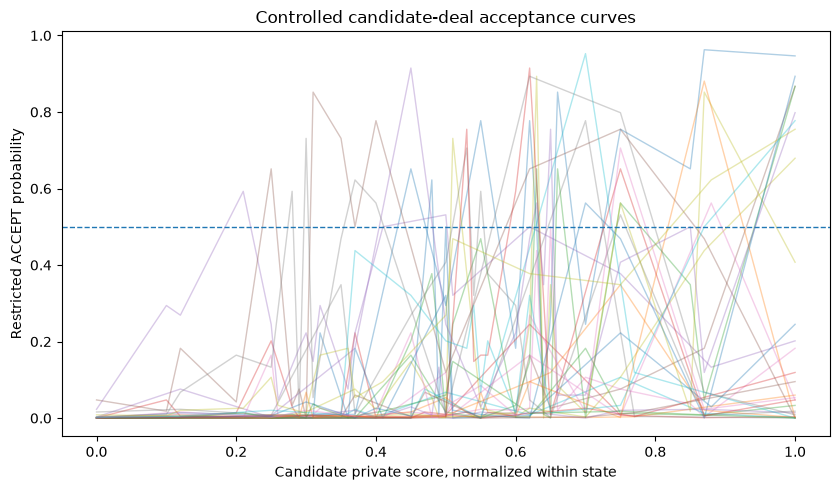

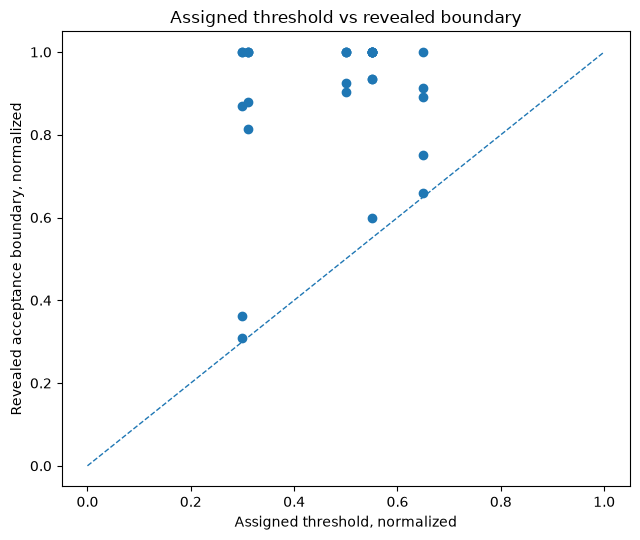

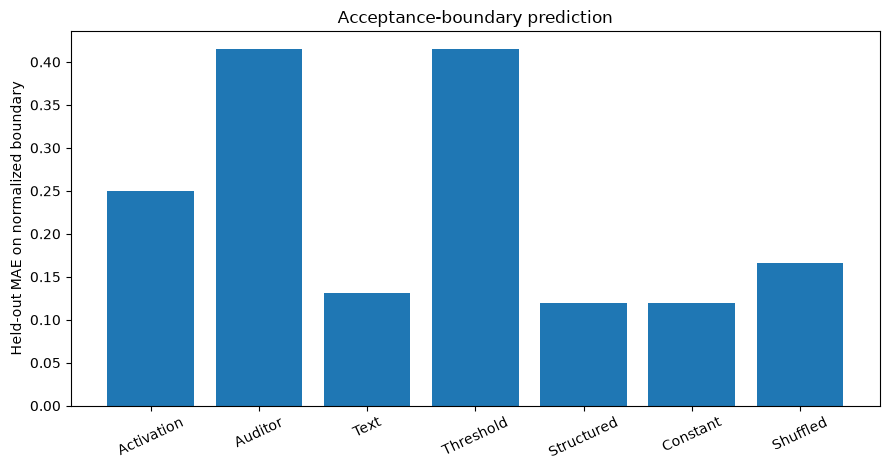

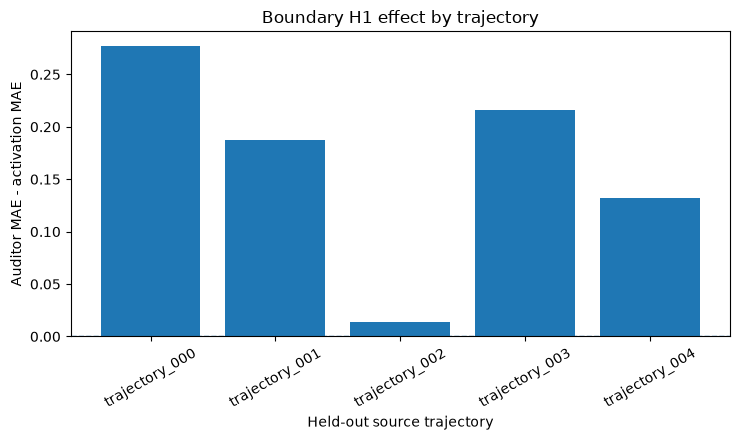

In [22]:
import matplotlib.pyplot as plt

# Figure 1: behavioral acceptance curves.
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for sid in state_ids:
    frame = (
        choice_df[
            (choice_df["state_id"] == sid)
            & (choice_df["legal"])
        ]
        .sort_values(
            "candidate_score_normalized"
        )
    )
    ax.plot(
        frame[
            "candidate_score_normalized"
        ],
        frame[
            "restricted_p_accept"
        ],
        alpha=0.35,
        linewidth=1,
    )
ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel(
    "Candidate private score, normalized within state"
)
ax.set_ylabel(
    "Restricted ACCEPT probability"
)
ax.set_title(
    "Controlled candidate-deal acceptance curves"
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "acceptance_curves.png",
    dpi=180,
)
plt.show()

# Figure 2: revealed boundary vs assigned threshold.
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(
    boundary_df[
        "assigned_threshold_norm"
    ],
    boundary_df[
        "rho_norm"
    ],
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel(
    "Assigned threshold, normalized"
)
ax.set_ylabel(
    "Revealed acceptance boundary, normalized"
)
ax.set_title(
    "Assigned threshold vs revealed boundary"
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "threshold_vs_revealed_boundary.png",
    dpi=180,
)
plt.show()

# Figure 3: method comparison.
fig, ax = plt.subplots(figsize=(9.0, 4.8))
ax.bar(
    [
        "Activation",
        "Auditor",
        "Text",
        "Threshold",
        "Structured",
        "Constant",
        "Shuffled",
    ],
    [
        ACTIVATION_MAE,
        AUDITOR_MAE,
        TEXT_MAE,
        THRESHOLD_MAE,
        STRUCTURED_MAE,
        CONSTANT_MAE,
        SHUFFLE_BOUNDARY_MAE,
    ],
)
ax.set_ylabel(
    "Held-out MAE on normalized boundary"
)
ax.set_title(
    "Acceptance-boundary prediction"
)
ax.tick_params(
    axis="x",
    rotation=25,
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "boundary_method_comparison.png",
    dpi=180,
)
plt.show()

# Figure 4: trajectory-level primary delta.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(
    trajectory_effects[
        "trajectory_id"
    ],
    trajectory_effects[
        "delta_auditor"
    ],
)
ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel(
    "Held-out source trajectory"
)
ax.set_ylabel(
    "Auditor MAE - activation MAE"
)
ax.set_title(
    "Boundary H1 effect by trajectory"
)
ax.tick_params(
    axis="x",
    rotation=30,
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "boundary_delta_by_trajectory.png",
    dpi=180,
)
plt.show()


## 22. Final result summary and manifest

Interpretation rules:

- the parent activation is the primary representation;
- candidate-level choices are used only to reveal the state-level boundary;
- the assigned threshold remains a required explicit-text baseline;
- `Delta > 0` favors activation;
- a positive auditor delta alone is not enough if activation fails against the conservative text/baseline suite;
- if fewer than two-thirds of states are uncensored, treat the boundary experiment as behaviorally underidentified.


In [23]:
result_summary = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "environment": "LLM-Deliberation",
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "parent_states": len(parent_states),
    "source_trajectories": len(trajectory_ids),
    "candidate_branches": int(len(choice_df)),
    "choice_valid_rate": CHOICE_VALID_RATE,
    "auditor_valid_rate": AUDITOR_VALID_RATE,
    "boundary_behavior_gate": boundary_gate,
    "target": {
        "name": "state-level revealed acceptance boundary",
        "scale": "normalized legal private-score range [0,1]",
        "parent_activation_timing": (
            "after controlled replay rule and before any candidate deal is revealed"
        ),
        "candidate_action": (
            "global next-token argmax; 1=ACCEPT, 0=REJECT"
        ),
    },
    "method_mae": {
        "activation": ACTIVATION_MAE,
        "matched_auditor": AUDITOR_MAE,
        "matched_auditor_valid_only": AUDITOR_VALID_ONLY_MAE,
        "trained_text": TEXT_MAE,
        "assigned_threshold": THRESHOLD_MAE,
        "structured": STRUCTURED_MAE,
        "constant_median": CONSTANT_MAE,
        "shuffled_activation": SHUFFLE_BOUNDARY_MAE,
    },
    "h1": {
        "delta_matched_auditor_minus_activation": DELTA_AUDITOR,
        "best_text_method": BEST_TEXT_METHOD,
        "best_text_mae": BEST_TEXT_MAE,
        "delta_best_text_minus_activation": DELTA_BEST_TEXT,
        "best_nonactivation_method": BEST_NONACTIVATION_METHOD,
        "best_nonactivation_mae": BEST_NONACTIVATION_MAE,
        "delta_best_nonactivation_minus_activation": DELTA_BEST_NONACTIVATION,
        "trajectory_cluster_bootstrap": bootstrap_summary,
    },
    "positive_control": {
        "assigned_threshold_activation_decode_mae": THRESHOLD_DECODE_MAE,
    },
    "interpretation_policy": (
        "Preserve the observed sign. A positive matched-auditor delta is insufficient "
        "unless activation remains competitive with the explicit threshold, trained text, "
        "structured, and constant controls. Boundary interpretation additionally requires "
        "the predeclared uncensored-state gate."
    ),
}

(TABLE_DIR / "result_summary.json").write_text(
    json.dumps(
        result_summary,
        indent=2,
    )
)

manifest = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "source_state_dir": str(SOURCE_STATE_DIR),
    "protocol_freeze": str(
        MANIFEST_DIR
        / "protocol_freeze.json"
    ),
    "trajectory_folds": str(
        DERIVED_DIR
        / "trajectory_folds.json"
    ),
    "parent_states": str(
        PARENT_STATE_DIR
    ),
    "candidate_banks": str(
        CANDIDATE_BANK_DIR
    ),
    "parent_activations": str(
        PARENT_ACTIVATION_DIR
        / "parent_all_layers.safetensors"
    ),
    "candidate_choices": str(
        CHOICE_DIR
    ),
    "auditor": str(
        AUDITOR_DIR
    ),
    "boundaries": str(
        TABLE_DIR
        / "revealed_acceptance_boundaries.csv"
    ),
    "predictions": str(
        TABLE_DIR
        / "heldout_boundary_predictions.csv"
    ),
    "result_summary": str(
        TABLE_DIR
        / "result_summary.json"
    ),
    "figures": sorted(
        str(path)
        for path in FIGURE_DIR.glob("*.png")
    ),
}

(MANIFEST_DIR / "notebook07_manifest.json").write_text(
    json.dumps(
        manifest,
        indent=2,
    )
)

print(
    json.dumps(
        result_summary,
        indent=2,
    )
)
print()
print("Notebook 07 complete.")
print(
    f"Result summary: "
    f"{TABLE_DIR / 'result_summary.json'}"
)
print(
    f"Run directory: "
    f"{RUN_OUTPUT_DIR}"
)

try:
    del model
    torch.cuda.empty_cache()
except Exception:
    pass


{
  "notebook_build": "latent-reservations-notebook07-llm-deliberation-acceptance-boundary-v1",
  "run_id": "20260814T095251Z",
  "environment": "LLM-Deliberation",
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "upstream_commit": "78e11e04ba89b9d888cb006f57bad696584a32f1",
  "parent_states": 30,
  "source_trajectories": 5,
  "candidate_branches": 490,
  "choice_valid_rate": 1.0,
  "auditor_valid_rate": 1.0,
  "boundary_behavior_gate": {
    "states": 30,
    "uncensored_states": 19,
    "uncensored_rate": 0.6333333333333333,
    "required_rate": 0.6666666666666666,
    "passed": false,
    "states_with_monotonicity_violation": 16
  },
  "target": {
    "name": "state-level revealed acceptance boundary",
    "scale": "normalized legal private-score range [0,1]",
    "parent_activation_timing": "after controlled replay rule and before any candidate deal is revealed",
    "candidate_action": "global next-token argmax; 1=ACCEPT, 0=REJECT"
  },
  "method_mae": {
    "activation": 0.24942